In [88]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, ShuffleSplit, cross_val_score
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, confusion_matrix,ConfusionMatrixDisplay, classification_report, f1_score, roc_auc_score,accuracy_score,recall_score,precision_score
import seaborn as sns
from sklearn.preprocessing import StandardScaler,minmax_scale
from sklearn.ensemble import RandomForestClassifier 
from sklearn.tree import DecisionTreeClassifier 
random_state=42

    A1    A2   A3    A4   A5   A6   A7   A8   A9   A10  ...  A16  A17  A18  \
0  1.0   6.0  4.0  12.0  5.0  5.0  3.0  4.0  1.0  67.0  ...  0.0  0.0  1.0   
1  2.0  48.0  2.0  60.0  1.0  3.0  2.0  2.0  1.0  22.0  ...  0.0  0.0  1.0   
2  4.0  12.0  4.0  21.0  1.0  4.0  3.0  3.0  1.0  49.0  ...  0.0  0.0  1.0   
3  1.0  42.0  2.0  79.0  1.0  4.0  3.0  4.0  2.0  45.0  ...  0.0  0.0  0.0   
4  1.0  24.0  3.0  49.0  1.0  3.0  3.0  4.0  4.0  53.0  ...  1.0  0.0  1.0   

   A19  A20  A21  A22  A23  A24  label  
0  0.0  0.0  1.0  0.0  0.0  1.0    1.0  
1  0.0  0.0  1.0  0.0  0.0  1.0    2.0  
2  0.0  0.0  1.0  0.0  1.0  0.0    1.0  
3  0.0  0.0  0.0  0.0  0.0  1.0    1.0  
4  0.0  0.0  0.0  0.0  0.0  1.0    2.0  

[5 rows x 25 columns]
--------------------------------------------------------------
                A1           A2          A3           A4           A5  \
count  1000.000000  1000.000000  1000.00000  1000.000000  1000.000000   
mean      2.577000    20.903000     2.54500    32.711

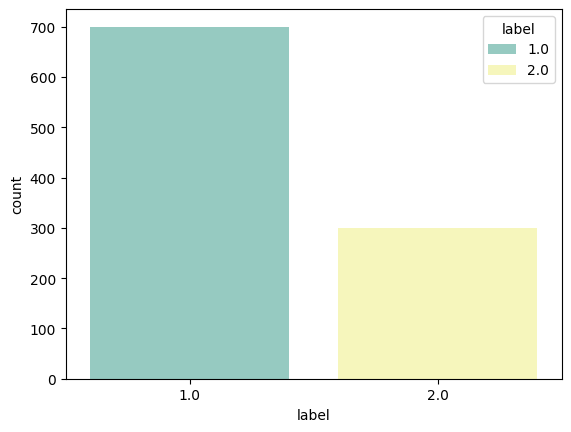

In [89]:
dt=np.genfromtxt("D:\\ISE_LAB\\ML-Newbie-Training\\Week 2\\Data\\german.data-numeric")
data=pd.DataFrame(data=dt, columns=['A'+str(i) for i in range(1,25)]+['label'])

print(data.head())
print('--------------------------------------------------------------')
print(data.describe())
print('--------------------------------------------------------------')
print(data.info())
print('--------------------------------------------------------------')
print(data.isnull().sum())
print('--------------------------------------------------------------')
sns.countplot(data=data,x=data['label'],hue='label',palette='Set3')
print(data['label'].count())

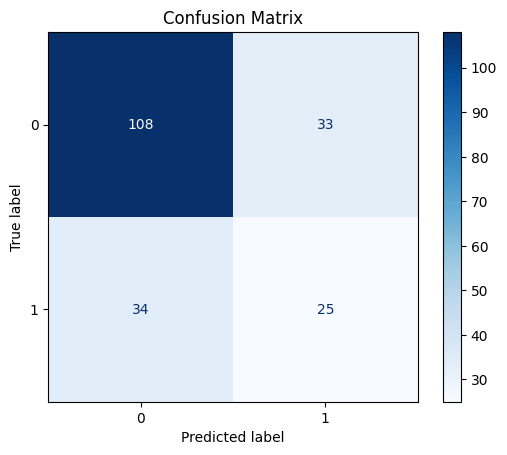

In [90]:
cost_matrix=np.array([[0,5],[1,0]])
scaler=StandardScaler()
x=data.drop('label',axis=1)
y=data['label']
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
#x_train=scaler.fit_transform(x_train)
#x_test=scaler.transform(x_test)


#Decc_tree



model = DecisionTreeClassifier(
    random_state=42
)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

cm = confusion_matrix(y_test, y_pred,labels=[1,2])
ac=accuracy_score(y_test,y_pred)
pc=precision_score(y_test,y_pred,pos_label=2)
rc=recall_score(y_test,y_pred,pos_label=2)
#print(ac,pc,rc)

cm = confusion_matrix(y_test, y_pred,labels=[1,2])
# Plotting with a nice color map
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title('Confusion Matrix')
plt.show()


In [91]:



roc=roc_auc_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print('F1: ',f1)
print('Roc: ',roc)



F1:  0.7632508833922261
Roc:  0.5948431301839163


In [92]:
# Utility functions
def grid_search(algorithm, n_jobs, dict_param):
    if algorithm == 'decision-tree':
        model = DecisionTreeClassifier()
    if algorithm == 'random-forest':
        model = RandomForestClassifier()
    classifier = GridSearchCV(estimator=model, cv=5, param_grid=dict_param,
                            n_jobs=n_jobs, scoring='f1')
    classifier.fit(X_train, y_train)
    print('Best model', end='')
    print(classifier.best_estimator_)
    return classifier.best_estimator_

def evaluate(model): 
    print("Train Accuracy :", accuracy_score(y_train, model.predict(X_train)))
    print("Train f1 score :", f1_score(y_train, model.predict(X_train)))  
    print("Train roc auc :", roc_auc_score(y_train, model.predict(X_train)))  
    print("Train Confusion Matrix:")
    print(confusion_matrix(y_train, model.predict(X_train)))
    print("-"*50)
    print("Test Accuracy :", accuracy_score(y_test, model.predict(X_test)))
    print("Test f1 score :", f1_score(y_test, model.predict(X_test)))
    print("Test roc auc :", roc_auc_score(y_test, model.predict(X_test)))  
    print("Test Confusion Matrix:")
    print(confusion_matrix(y_test, model.predict(X_test)))

def plot_learning_curve(estimator, title, label_curve, X, y, ylim=None, cv=None,
                        n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5), new_plot=False,
                        idx_color=0):
    # Khởi tạo bức ảnh mới với thư viện plot lib 
    if new_plot:
        # plt.figure()
        plt.title(title)
        plt.xlabel("Training examples")
        plt.ylabel("Score")
        plt.grid()
    # chú thích nếu có 
    if ylim is not None:
        plt.ylim(*ylim)                             
        
    # thực hiện training model, ghi nhận các giá trị trong quá trình training 
    # cv = số fold cross validate, số phần bộ dữ liệu được chia để thực hiện training testing.
    # train_sizes = mảng tỉ lệ, các tỉ lệ được hệ thống chọn làm điểm dừng để thực hiện 1 testing 
    #  train_sizes = [0.3, 0.5] => hệ thống lấy 30 % dữ liệu để train và thực hiện test, tương tự 50 % ..
    # scoring = hàm mục tiêu để đánh giá chất lượng mô hình và vẽ lên đồ thị 
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring="f1")
    # Lấy trung bình cộng các giá trị output của các fold 
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    # thực hiện vẽ các giá trị số lên đồ thị với màu vừa được random 
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='r')
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='g')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='r',
             label=label_curve['test'])
    plt.plot(train_sizes, train_scores_mean, 'o-', color='g',
             label=label_curve['train'])

    plt.legend(loc="best")
    return plt

Best modelDecisionTreeClassifier(max_depth=5, min_samples_leaf=20)


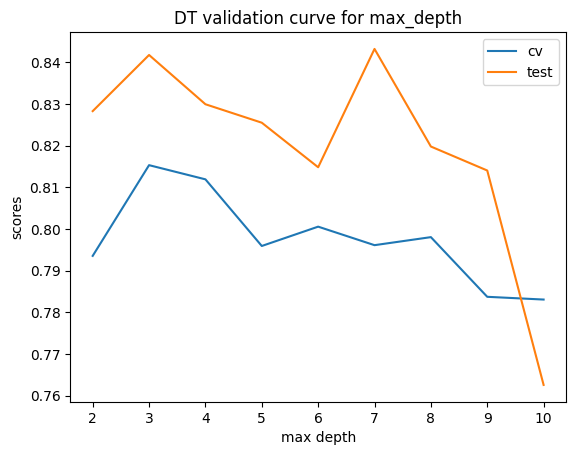

In [93]:
# Trước hết, hãy thử khảo sát DT với tham số max_depth
cv_accuracies_by_depth, test_accuracies_by_depth= [], []
max_depth_values= np.arange(2,11)

for curr_max_depth in max_depth_values:
  tree= DecisionTreeClassifier(random_state=random_state, max_depth=curr_max_depth)
  
  # cross-validation
  val_scores= cross_val_score(estimator=tree, X=X_train, y=y_train, cv=5, scoring='f1')
  cv_accuracies_by_depth.append(val_scores.mean())

  # test
  tree.fit(X_train, y_train)
  curr_pred= tree.predict(X_test)
  test_accuracies_by_depth.append(f1_score( y_test,curr_pred))

# Plot 
plt.plot(max_depth_values, cv_accuracies_by_depth, label='cv')
plt.plot(max_depth_values, test_accuracies_by_depth, label='test')
plt.legend()
plt.xlabel('max depth')
plt.ylabel('scores')
plt.title('DT validation curve for max_depth')
# Thử sử dụng GridSearchCV để khảo sát
dict_param = {
    'max_depth': [2, 3, 5, 7, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'criterion': ["gini", "entropy"]
}
best_tree = grid_search('decision-tree', n_jobs=-1, dict_param=dict_param)


Top 10 feature importances
Feature  0 - 0.40445005922715943
Feature  1 - 0.17066428015343657
Feature  2 - 0.14261352910286315
Feature  3 - 0.07120344185816782
Feature  4 - 0.05428847945598893
Feature  5 - 0.05400258515142507
Feature  6 - 0.04007488290946428
Feature  7 - 0.03813781829612112
Feature  8 - 0.015091674891623292
Feature  9 - 0.009473248953750433
Feature  10 - 0.0
Feature  11 - 0.0
Feature  12 - 0.0
Feature  13 - 0.0
Feature  14 - 0.0
Feature  15 - 0.0
Feature  16 - 0.0
Feature  17 - 0.0
Feature  18 - 0.0
Feature  19 - 0.0
Feature  20 - 0.0
Feature  21 - 0.0
Feature  22 - 0.0
Feature  23 - 0.0


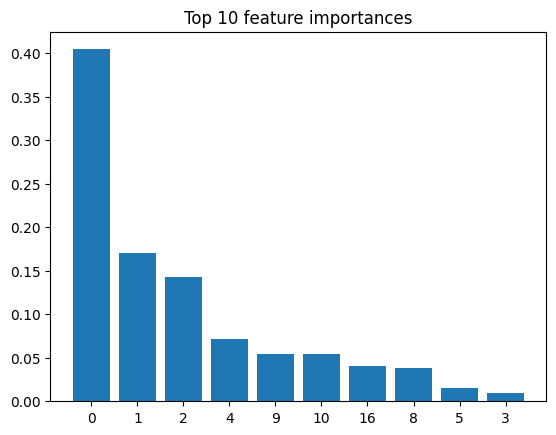

In [94]:
# Nhận xét về độ quan trọng của từng feature
importances = best_tree.feature_importances_
indices = np.argsort(importances)[::-1]
print('Top 10 feature importances')
for i in range(24):
    print('Feature ', i, '-', importances[indices[i]])

indices = indices[:10]
plt.figure()
plt.title('Top 10 feature importances')
plt.bar(range(10), importances[indices])
plt.xticks(range(10), indices)
plt.show()

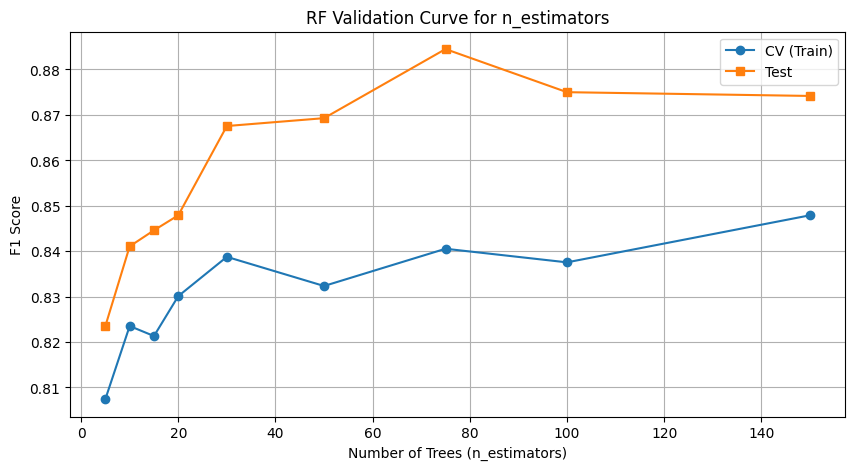

In [95]:
# 1. Khởi tạo danh sách lưu kết quả
cv_scores_rf, test_scores_rf = [], []
num_trees = [5, 10, 15, 20, 30, 50, 75, 100, 150]

# 2. Vòng lặp khảo sát qua từng n_estimators
for n in num_trees:
    # Khởi tạo Random Forest với n cây
    rf_model = RandomForestClassifier(n_estimators=n, random_state=42)
    
    # Tính Cross-validation (5-fold) dùng F1-score
    # Đảm bảo y_train đã được map về 0 và 1 để tránh lỗi ValueError
    val_scores = cross_val_score(estimator=rf_model, X=X_train, y=y_train, cv=5, scoring='f1')
    cv_scores_rf.append(val_scores.mean())

    # Huấn luyện và kiểm tra trên tập test
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)
    test_scores_rf.append(f1_score(y_test, y_pred_rf))

# 3. Vẽ đồ thị khảo sát (Validation Curve)
plt.figure(figsize=(10, 5))
plt.plot(num_trees, cv_scores_rf, 'o-', label='CV (Train)')
plt.plot(num_trees, test_scores_rf, 's-', label='Test')

plt.title('RF Validation Curve for n_estimators')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.show()

Best modelRandomForestClassifier(max_depth=15, max_features=6, min_samples_leaf=5,
                       n_estimators=75)


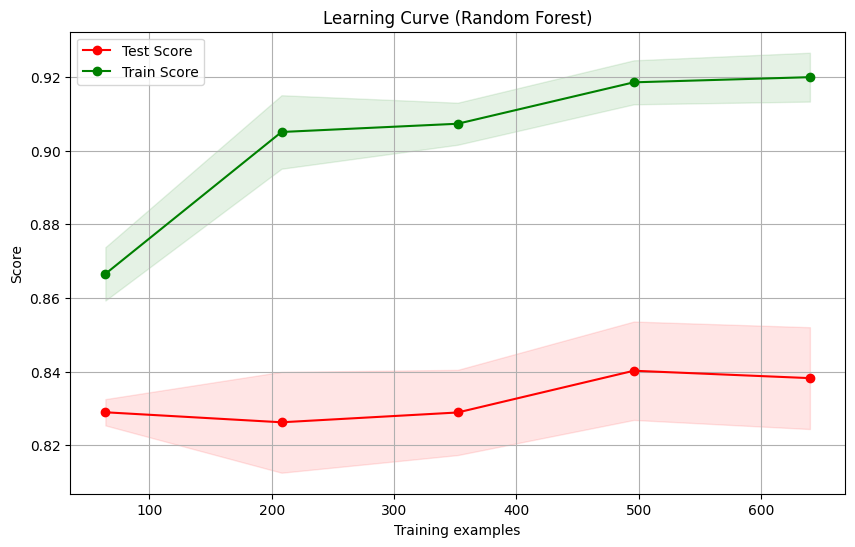

Top 10 feature importances (Random Forest):
1. A1: 0.1704
2. A4: 0.1336
3. A10: 0.1150
4. A2: 0.1143
5. A3: 0.0800
6. A6: 0.0555
7. A5: 0.0539
8. A9: 0.0460
9. A16: 0.0330
10. A8: 0.0317


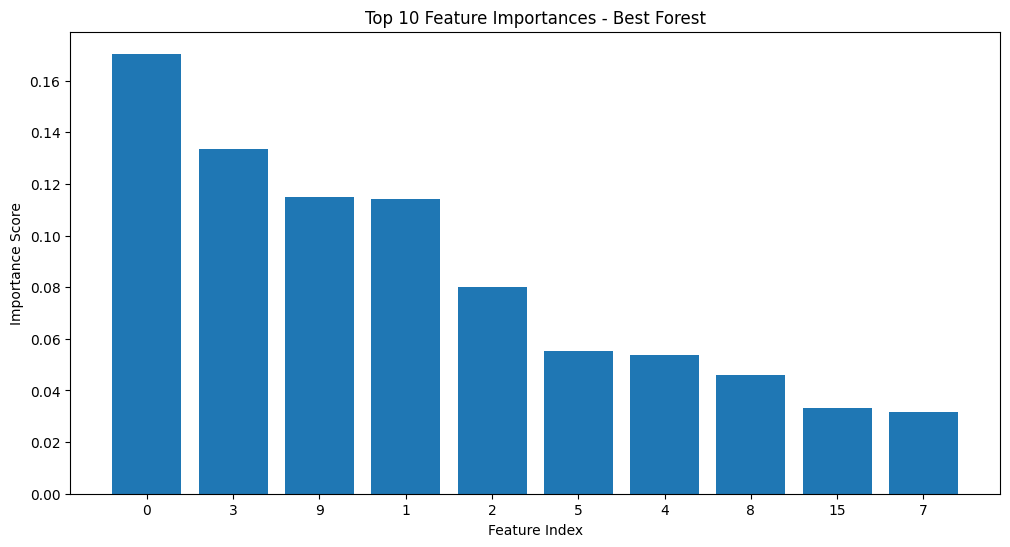

In [96]:
# Tìm mô hình tốt nhất với bộ tham số đã cho
dict_param = {
    'max_depth': [3, 11, 15, 24, 27], 
    'min_samples_leaf': [1, 5, 7, 9, 15, 24],
    'max_features':  [4, 6, 10, 16],
    'n_estimators': [75]
}
best_forest = grid_search('random-forest', n_jobs=-1, dict_param=dict_param)
# Thiết lập nhãn cho đồ thị
label_curve = {'train': 'Train Score', 'test': 'Test Score'}

# Vẽ đồ thị Learning Curve
plt.figure(figsize=(10, 6))
plot_learning_curve(best_forest, "Learning Curve (Random Forest)", 
                   label_curve, X_train, y_train, cv=5, n_jobs=-1, new_plot=True)
plt.show()
# Lấy độ quan trọng của các đặc trưng
importances = best_forest.feature_importances_
indices = np.argsort(importances)[::-1]

print('Top 10 feature importances (Random Forest):')
for i in range(min(10, len(importances))):
    # Nếu X_train là DataFrame, ta lấy được tên cột. Nếu là mảng, ta dùng index.
    feature_name = X_train.columns[indices[i]] if hasattr(X_train, 'columns') else f"Feature {indices[i]}"
    print(f"{i+1}. {feature_name}: {importances[indices[i]]:.4f}")

# Vẽ biểu đồ cột
plt.figure(figsize=(12, 6))
plt.title('Top 10 Feature Importances - Best Forest')
plt.bar(range(min(10, len(importances))), importances[indices[:10]], align='center')
plt.xticks(range(min(10, len(importances))), indices[:10]) 
plt.xlabel('Feature Index')
plt.ylabel('Importance Score')
plt.show()